# Orientation

## Frame of reference

The IMU has its own "hardware" body frame, which is defined by the orientation of the sensors, and it's drawn on the front of component. On the first version of the prototype, it's mounted as follows on the perfboard:

<img src="./frames/body-hw.png" alt="Hardware body frame" width="200" height="250">

However, this application will use the following right-handed system of coordinates (x: right, y: forwards, z: up) for the "software" body frame:

<img src="./frames/body-sw.jpg" alt="Software body frame" width="250" height="250">

The origin lies at the roughly the center of the device, mounted on the chest of the user. 

The world frame (i.e. an anchored/fixed system of coordinates independent of the device), in contrast, is only partially observable. The z-axis is defined in the direction of gravity, and the x and y axes are orthogonal to it and between each other, but their orientation is not defined. The body frame and world frame are generally not aligned, 

The goal of this notebook is to compute the orientation of the device with respect to the world frame, given the measurements from the IMU, to later subtract the gravity vector from the measured acceleration. 

## Rotations in 3D space: Euler Angles

Euler angles were chosen because they are easier to understand.

Basic active rotations of a vector around each axis can be represented by pre-multiplying said column vector by a rotation matrix. If $\phi$ is the roll angle (i.e., rotation around the x axis), $\theta$ is the pitch angle (i.e. rotation around y axis), and $\psi$ is the yaw angle (i.e. rotation around z axis), the rotation matrices for roll, pitch and yaw rotations are defined as follows:

$$
R_z(\psi) = \begin{bmatrix}
\cos\psi & -\sin\psi & 0 \\
\sin\psi & \cos\psi & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

$$
R_y(\theta) = \begin{bmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}
$$

$$
R_x(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

These matrices can be combined in different orders to represent a complete rotation in space. The order matters because matrix multiplication is not commutative. A common convention is to perform a right-handed rotation (i.e. aligning the thumb with the axis, rotation follows the direction of the fingers when closing the palm) around z axis (yaw), then around the y axis (pitch), and finally around the x axis (roll). The combined rotation matrix is given by:

$$
R_{world\rightarrow body} = R_x(\phi) \cdot R_y(\theta) \cdot R_z(\psi) = \begin{bmatrix}
\cos\theta \cos\psi & - \cos\theta \sin\psi & \sin\theta \\
\cos\phi \sin\psi + \sin\phi \sin\theta \cos\psi & \cos\phi \cos\psi - \sin\phi \sin\theta \sin\psi & - \sin\phi \cos\theta \\
\sin\phi \sin\psi - \cos\phi \sin\theta \cos\psi & \sin\phi \cos\psi + \cos\phi \sin\theta \sin\psi & \cos\phi \cos\theta
\end{bmatrix}
$$

If $\bm{g_{world}} = [0, 0, -g]^T$ is the gravity vector in the world frame, where $g = 9.80665 \text{ m/s}^2$, then the gravity vector in the body frame is given by:

$$
\bm{g_{body}} = R_{world\rightarrow body} \cdot \bm{g_{world}} = \begin{bmatrix}
-g \sin\theta \\
g \cos\theta \sin\phi \\
-g \cos\theta \cos\phi
\end{bmatrix}
$$ 

The accelerometer measures the specific force acting on the device (force per unit of mass, the acceleration due to all forces except for gravity):

$$
\mathbf a_{measured} = \mathbf a_{linear} - \mathbf g_{body}
$$
When the device is stationary, $a_{linear} = \bm{0}$. This yields the opposite of the gravity vector in the body frame:
$$
\mathbf a_{measured} = \mathbf a_{meas} = -\mathbf g_{body} = \begin{bmatrix}
g \sin\theta \\
-g \cos\theta \sin\phi \\
g \cos\theta \cos\phi
\end{bmatrix}
$$
This equation will be used below to compute the roll and pitch angles from the accelerometer measurements.

*Side note*:

Since rotation matrices verify that $ \bm{R}(\theta)^{-1} = \bm{R}(\theta)^T = \bm{R}(-\theta) $, the reverse rotation matrix can be computed as:

$$
\bm{R_{body\rightarrow world}} = \bm{R_{world\rightarrow body}}^{-1} = \bm{R_{world\rightarrow body}}^T = \bm{R_z(\psi)}^T \cdot \bm{R_y(\theta)}^T \cdot \bm{R_x(\phi)}^T = \bm{R_z(-\psi)} \cdot \bm{R_y(-\theta)} \cdot \bm{R_x(-\phi)}
$$

## Sensor fusion: complementary filter

### Classical formula

Conceptually, sensor fusion consists on estimating a magnitude (in this case, the roll and pitch) leveraging data from different sensors. The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

On continuous time, the idea is to apply a low-pass effect on the angle computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, the classical formula for the complementary filter is given by:

$$
\phi_i = \alpha_{c} \left(\theta_{i-1} + w_{x, i} \cdot \Delta t\right) + (1 - \alpha_{c}) \phi_{acc} \\
\theta_i = \alpha_{c} \left(\theta_{i-1} + w_{y, i} \cdot \Delta t\right) + (1 - \alpha_{c}) \theta_{acc}
$$

Where $0 < \alpha_{c} = \frac{\tau}{\tau + \Delta t} < 1$ is a tuning parameter, $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

To compute the orientation from acceleration data, stationary periods can be used, where the only force acting on the device is gravity. For roll, do:
$$
\frac{a_{meas,y}}{a_{meas,z}} = \frac{-g \cos\theta \sin\phi}{-g \cos\theta \cos\phi} \\
\phi_{acc,1} = {atan2}(-a_{meas,y}, a_{meas,z})
$$
Where $\phi_{acc,1} \in [-180^\circ, 180^\circ]$. For pitch, do: 

$$
(a_{meas,y})^2 + (a_{meas,z})^2 = g^2 \cos^2\theta (\overbrace{\sin^2\phi + \cos^2\phi}^{1}) = g^2 \cos^2\theta \\
\sqrt{(a_{meas,y})^2 + (a_{meas,z})^2} = g |\cos\theta| \\
\frac{a_{meas,x}}{\sqrt{(a_{meas,y})^2 + (a_{meas,z})^2}} = \frac{g \sin\theta}{g |\cos\theta|}  \\
$$
Let $r = \sqrt{(a_{meas,y})^2 + (a_{meas,z})^2}$, then using the definition of the absolute value function, there are two solutions for $\theta$:
$$
\theta_{acc,1}= {atan2}(a_{meas,x}, r), \text{when } \cos\theta \geq 0 \\
\theta_{acc,2}= {atan2}(a_{meas,x}, -r), \text{when } \cos\theta < 0 \\
$$
Where $\theta_{acc,1}, \theta_{acc,2} \in [-90^\circ, 90^\circ]$. To find $\phi_{acc, 2}$, consider that acceleration has to be the same independent of angles:

$$
a_{meas,y} = -g \cos\theta_{acc,1} \sin\phi_{acc,1} = -g \cos\theta_{acc,2} \sin\phi_{acc,2} \\
a_{meas,z} = g \cos\theta_{acc,1} \cos\phi_{acc,1} = g \cos\theta_{acc,2} \cos\phi_{acc,2}
$$
The relationship holds provided that:
$$
\cos\theta_{acc,2} = -\cos\theta_{acc,1} = \cos(\theta_{acc,1} + 180^\circ) \\
sin\phi_{acc,2} = -\sin\phi_{acc,1} = \sin(\phi_{acc,1} + 180^\circ) \\
$$
Lastly,
$$
\phi_{acc,2} = \phi_{acc,1} + 180^\circ 
$$

The $\psi$ angle can't be computed from the accelerometer data, since the rotation around the gravity vector is unobservable from acceleration. Another point of reference, such as a magnetometer, would be needed to compute this angle. As a consequence, the complementary filter can only be applied to roll and pitch angles, while the yaw angle can only be computed from the gyroscope data. However, since common calisthenics movements happen mostly on the sagital plane and a minor set on the frontal plane of the human body, the XY plane can be oriented to correspond with the plane of least importance, i.e. the transverse plane. As a reference, the following figure shows the three planes of movement of the human body: 

<img src="../../docs/misc/planes-of-motion-human-body.webp" alt="Coordinate system" width="400" height="300">

The previous formulas assume that gravity is the only force acting on the device, but that is not usually the case in this application. A possible solution involves changing $\alpha_{c}$ to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple way to detect stationarity that has been used across notebooks is to check that: 

$$
| ||\mathbf{a}|| - \mu_{a} | \leq k \sigma_{a} \\
| ||\mathbf{\omega}|| - \mu_{\omega}| \leq k \sigma_{\omega} 
$$ 
  
Where $\mu$ and $\sigma$ are the mean and standard deviation of norms of a set of stationary samples and $k$ is chosen so that it spans most stationary samples (e.g. $k = 3$, which covers 99.7% of them according to the empirical rule). More complex methods (e.g. discard samples at the beginning and end of a stationary interval, or requiring a minimum length) have been found to not be suitable because additional conditions may not be met at all with real exercise data.

### Corrected formula

The classical formula has a flaw. On the first term, where gyro is numerically integrated with the Euler's method, it assumes that the "roll", "pitch", and "yaw" rates as meas by the IMU are the Euler angle derivatives:

$$
\frac{d\phi}{dt} = \dot \phi= w_{x} \\
\frac{d\theta}{dt} = \dot \theta= w_{y} \\
\frac{d\psi}{dt} = \dot \psi= w_{z}
$$

But this is not generally true. Euler angles derivatives are related to the IMU angular rates by a non-linear transformation (Euler kinematical equations). Based on the source listed below, the previously defined rotation matrices, a CAS (computer algebra system), the relationship is:

$$
\begin{bmatrix}
\omega_x \\
\omega_y \\
\omega_z
\end{bmatrix} = \begin{bmatrix}
1 & 0 & -\sin\theta \\
0 & \cos\phi & - \sin\phi \cos\theta \\
0 & \sin\phi & \cos\phi \cos\theta
\end{bmatrix} \cdot \begin{bmatrix}
\dot \phi \\
\dot \theta \\
\dot \psi
\end{bmatrix}
$$

Taking the inverse of the above matrix with a CAS:

$$
\bm{\dot \Phi} = \begin{bmatrix}
\dot \phi \\
\dot \theta \\
\dot \psi
\end{bmatrix} = \begin{bmatrix}
1 & -\sin\phi \tan\theta & \cos\phi \tan\theta \\
0 & \cos\phi & \sin\phi \\
0 & -\frac{\sin\phi}{\cos\theta} & \frac{\cos\phi}{\cos\theta}
\end{bmatrix} \cdot \begin{bmatrix}
w_{x} \\
w_{y} \\
w_{z} 
\end{bmatrix}
$$

Notice that this matrix is singular when $\theta = \pm 90^\circ$, probably related to gimbal lock (loss of one degree of freedom when the other two rotation axes become aligned). This is a limitation of Euler angles, and as a countermeasure pitch was chosen to correspond with the frontal plane, where the range of motion is much more limited, and roll to correspond with the sagittal plane, where the range of motion is much larger. This does not remove the necessity to implement additional checks on the code to prevent division by zero.

The corrected formula for the complementary filter using the true Euler angles and trapezoidal integration instead of Euler is then:

$$
\phi_i = \alpha_{c} \left(\phi_{i-1} + \frac{\dot \phi_{i-1} + \dot \phi_{i}}{2} \cdot \Delta t\right) + (1 - \alpha_{c}) \phi_{acc} \\
\theta_i = \alpha_{c} \left(\theta_{i-1} + \frac{\dot \theta_{i-1} + \dot \theta_{i}}{2} \cdot \Delta t\right) + (1 - \alpha_{c}) \theta_{acc}
$$

Sources:

* ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

* ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

* [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)

* [Vector Derivatives (the Equation of Coriolis) and the Angular Velocity Vector](https://www.youtube.com/watch?v=-OyRCgv-hPs)

* [Euler Angles and the Euler Rotation Sequence](https://www.youtube.com/watch?v=GJBc6z6p0KQ)

* [Computing Euler Angles: The Euler Kinematical Equations and Poisson’s Kinematical Equations](https://www.youtube.com/watch?v=9GZjtfYOXao)

* [Euler (gimbal lock) Explained](https://www.youtube.com/watch?v=zc8b2Jo7mno)

* [Wikipedia: Gimbal Lock](https://en.wikipedia.org/wiki/Gimbal_lock)

* [Rotation Matrix](https://en.wikipedia.org/wiki/Rotation_matrix)

* [68-95-99.7 Rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule#Table_of_numerical_values)

* [Wikipedia: Specific force](https://en.wikipedia.org/wiki/Specific_force)

* [Wikipedia: List of trigonometric identities](https://en.wikipedia.org/wiki/List_of_trigonometric_identities#Shifts_and_periodicity)

## Setup

In [52]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

sixFaceStationaryCaptures = [
    "../2-noiseReduction/output/pos-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]
tiltedStationaryCaptures = [
    "../2-noiseReduction/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]
stationaryCaptures = [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]

simpleRotationsCaptures = [
    "../2-noiseReduction/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]

realExerciseCaptures = [
    "../2-noiseReduction/output/dips-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/dips-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/dips-3-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
    "../2-noiseReduction/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()

## Transform hardware frame to software frame

The hardware frame has to be transformed through software with a linear transformation:

$$
\boldsymbol{a}_{sw}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{a}_{hw}
$$

$$
\boldsymbol{\omega}_{sw}
=
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & -1 & 0
\end{bmatrix}
\cdot
\boldsymbol{\omega}_{hw}
$$

or more simply with the following assignments:
$$
a_{sw, y} = a_{hw, z} \\
a_{sw, z} = -a_{hw, y}
$$
$$
\omega_{sw, y} = \omega_{hw, z} \\
\omega_{sw, z} = -\omega_{hw, y}
$$

In [53]:
def transformHWToSWFrame(a, w):
    aHw = a.copy()
    wHw = w.copy()

    a[:, 0] = aHw[:, 0]
    a[:, 1] = aHw[:, 2]
    a[:, 2] = -aHw[:, 1]

    w[:, 0] = wHw[:, 0]
    w[:, 1] = wHw[:, 2]
    w[:, 2] = -wHw[:, 1]

## Analyze inverse tangent behavior

`math.atan2(y, x)` (or its vector form, `np.atan(y, x)`) returns the angle in the interval $[-\pi, \pi]$ between the positive x axis and the point (x,y) in the plane (i.e. the angle of the vector from the origin to (x, y)). It differs from the regular `math.atan(y/x)` because it uses the signs of both arguments to determine the correct quadrant.

$$
\operatorname{atan2}(y,x)=\begin{cases}
\arctan\!\left(\dfrac{y}{x}\right) & x>0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)+\pi & x<0,\ y\ge 0\\[6pt]
\arctan\!\left(\dfrac{y}{x}\right)-\pi & x<0,\ y<0\\[6pt]
+\dfrac{\pi}{2} & x=0,\ y>0\\[6pt]
-\dfrac{\pi}{2} & x=0,\ y<0\\[6pt]
\text{undefined} & x=0,\ y=0
\end{cases}
$$

Examples:
- `atan2(1,1) = π/4`  
- `atan2(1,-1) = 3π/4`  
- `atan2(-1,-1) = -3π/4`  
- `atan2(-1,1) = -π/4`  
- `atan2(0,-1) = π`

Problems:

1. The function is vulnerable to rapid oscillations when the angle moves close to the negative x axis (i.e. y close to 0 by excess or defect). To fix this, there are many options, from cheaper/simpler to more complex/expensive:

    * Use a tolerance band within which y = 0 is assigned. The tolerance can't larger than around $0.1-0.2 \, \frac{\text{m}}{\text{s}^2}$, as it would start to filter out real, human scale motions, like the initial phase of a walk, a gentle motion of a vehicle, etc. Also consider interaction the complementary filter's $\alpha_c$: the lower the $\alpha_c$, the lower the tolerance should be, as the accelerometer contribution is larger. (chosen option)

    * Use hysterisis (small non-linearity): the output depends on the current as well as previous inputs and/or the direction of the change. If y is positive and greater than a tolerance, switch to positive. If it's negative and less than a tolerance, switch to negative. Otherwise use a previous state.

    * Unwrap the angle so that it evolves continuously over time. Not necessary for this application.

    * Sin/cos filtering: compute the angle, then remap it to coordinates with cosine and sine functions for the x and y axes, respectively. Then apply an exponential smoothing effect on both series. Lastly recompute the angle with the inverse tangent function. 

2. Some special function evaluations (e.g. involving 0, infinity, NaN) depend on the implementation. 

Sources:
- <https://en.wikipedia.org/wiki/Atan2>

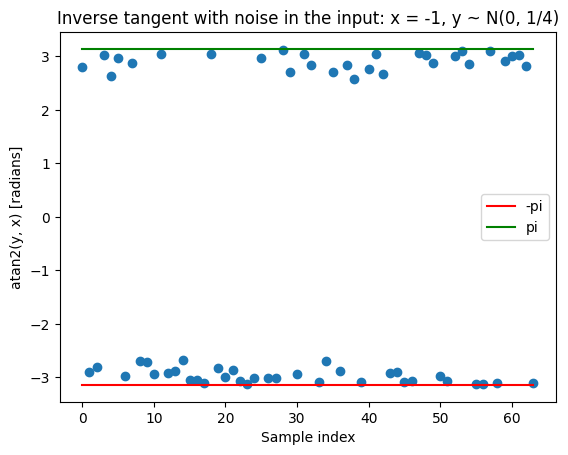

In [54]:
noiseSamples = 64
x = -1 * np.ones(noiseSamples)
y = stats.norm.rvs(loc=0, scale=1 / 4, size=noiseSamples)
plt.plot(np.atan2(y, x), "o")
plt.plot(-np.pi * np.ones(noiseSamples), "r", label="-pi")
plt.plot(np.pi * np.ones(noiseSamples), "g", label="pi")
plt.title("Inverse tangent with noise in the input: x = -1, y ~ N(0, 1/4)")
plt.xlabel("Sample index")
plt.ylabel("atan2(y, x) [radians]")
plt.legend()
plt.show()

In [55]:
print(f"Evaluation of atan2 function for special cases:")
print(f"atan2(1, 0) = {math.atan2(1, 0)}")
print(f"atan2(-1, 0) = {math.atan2(-1, 0)}")
print(f"atan2(0, 0) = {math.atan2(0, 0)}")
print(f"atan2(inf, 1) = {math.atan2(float('inf'), 1)}")
print(f"atan2(-inf, 1) = {math.atan2(float('-inf'), 1)}")
print(f"atan2(inf, -1) = {math.atan2(float('inf'), -1)}")
print(f"atan2(-inf, -1) = {math.atan2(float('-inf'), -1)}")
print(f"atan2(1, inf) = {math.atan2(1, float('inf'))}")
print(f"atan2(1, -inf) = {math.atan2(1, float('-inf'))}")
print(f"atan2(-1, inf) = {math.atan2(-1, float('inf'))}")
print(f"atan2(-1, -inf) = {math.atan2(-1, float('-inf'))}")

Evaluation of atan2 function for special cases:
atan2(1, 0) = 1.5707963267948966
atan2(-1, 0) = -1.5707963267948966
atan2(0, 0) = 0.0
atan2(inf, 1) = 1.5707963267948966
atan2(-inf, 1) = -1.5707963267948966
atan2(inf, -1) = 1.5707963267948966
atan2(-inf, -1) = -1.5707963267948966
atan2(1, inf) = 0.0
atan2(1, -inf) = 3.141592653589793
atan2(-1, inf) = -0.0
atan2(-1, -inf) = -3.141592653589793


In [56]:
def modAtan2(y, x):
    #     accelTol = 0.15
    #     if abs(y) > accelTol:
    #         return math.atan2(y, x)
    #     else:
    #         return math.atan2(0, x)
    return math.atan2(y, x)

## Estimate angles from accelerometer data

Euler-angles decomposition of gravity is ambiguous. For every instant, there are the two possible solutions for roll and pitch as was mentioned above. Both the main and the alternative solutions will be computed and one will be chosen to be fused based on similarity with the previous orientation.

In [57]:
def angleDistanceInDegrees(a, b):
    return abs(wrapInDegrees(a - b))


# Maps an angle to the range [-180, 180] degrees
def wrapInDegrees(angle):
    return (angle + 180.0) % 360.0 - 180.0
    # return math.fmod(angle + 180.0, 360.0) - 180.0  // Maybe better for floating point, but results differ


def computeAccelAngleCandidates(a):
    r = math.sqrt(a[1] ** 2 + a[2] ** 2)

    mainRoll = 180.0 / np.pi * modAtan2(-a[1], a[2])
    mainPitch = 180.0 / np.pi * modAtan2(a[0], r)

    alternativeRoll = wrapInDegrees(mainRoll + 180.0)
    alternativePitch = 180.0 / np.pi * modAtan2(a[0], -r)
    # alternativePitch = math.copysign(180.0 - abs(mainPitch), mainPitch) # Equivalent but harder to understand

    return np.array([mainRoll, mainPitch]), np.array(
        [alternativeRoll, alternativePitch]
    )

## Estimate angles from gyroscope data

Compute orientation both by simple integration and with the non-linear transformation to compare the estimates. 

Use initial conditions from the accelerometer solution. Notice than the homogeneous solution is not always correct, since I may have started recording on a different position than neutral (sensor strapped to the chest). 

In [58]:
integrateEuler = lambda previous, slopeBeginning, step: previous + slopeBeginning * step
integrateTrapezoid = (
    lambda previous, slopeBeginning, slopeEnd, step: previous
    + (slopeBeginning + slopeEnd) * step / 2
)


def gyroOnlyOrientationDirectIntegration(a, w, dt):
    pseudoEulerAnglesGyro = np.zeros_like(w)
    mainAnglesAccel, _ = computeAccelAngleCandidates(a[0, :])
    pseudoEulerAnglesGyro[0, 0] = mainAnglesAccel[0]
    pseudoEulerAnglesGyro[0, 1] = mainAnglesAccel[1]
    for i in range(1, pseudoEulerAnglesGyro.shape[0]):
        pseudoEulerAnglesGyro[i, :] = integrateEuler(
            pseudoEulerAnglesGyro[i - 1, :], w[i, :], dt
        )

    return pseudoEulerAnglesGyro


def gyroOnlyOrientationNonLinearTransform(a, w, dt):
    eulerAnglesGyro = np.zeros_like(w)
    mainAnglesAccel, _ = computeAccelAngleCandidates(a[0, :])
    eulerAnglesGyro[0, 0] = mainAnglesAccel[0]
    eulerAnglesGyro[0, 1] = mainAnglesAccel[1]
    eulerRates = computeEulerRates(eulerAnglesGyro[0, :], w[0, :])
    for i in range(1, eulerAnglesGyro.shape[0]):
        prevEulerRates = eulerRates
        eulerRates = computeEulerRates(eulerAnglesGyro[i - 1, :], w[i, :])
        eulerAnglesGyro[i, :] = integrateTrapezoid(
            eulerAnglesGyro[i - 1, :], prevEulerRates, eulerRates, dt
        )

    return eulerAnglesGyro


def computeEulerRates(prevEulerAngle, w):
    rollRad = prevEulerAngle[0] * np.pi / 180.0
    pitchRad = prevEulerAngle[1] * np.pi / 180.0
    epsilon = 0.0
    RADIUS_FROM_SINGULARITY = 5 * np.pi / 180.0
    if (
        abs(np.pi / 2.0 - pitchRad) <= RADIUS_FROM_SINGULARITY
        or abs(-np.pi / 2.0 - pitchRad) <= RADIUS_FROM_SINGULARITY
    ):
        epsilon = 1e-1
    T = np.array(
        [
            [
                1,
                -math.sin(rollRad)
                * math.sin(pitchRad)
                / (epsilon + math.cos(pitchRad)),
                math.cos(rollRad) * math.sin(pitchRad) / (epsilon + math.cos(pitchRad)),
            ],
            [0, math.cos(rollRad), math.sin(rollRad)],
            [
                0,
                -math.sin(rollRad) / (epsilon + math.cos(pitchRad)),
                math.cos(rollRad) / (epsilon + math.cos(pitchRad)),
            ],
        ]
    )

    return T @ w

## Estimate movement detection tolerance

In [59]:
stationaryChecker.computeTolerances(stationaryCaptures)

Acceleration norms:
	Mean = 9.803694
	Stdev = 0.078789 (tol = 0.236366)
	Stationary interval = [9.567327, 10.040060]
Gyroscope norms:
	Mean = 0.141652
	Stdev = 1.273801 (tol = 3.821403)
	Stationary interval = [-3.679752, 3.963055]


## Estimate angles with the complementary filter

1. The gyroscope is first integrated to predict the next roll and pitch angles. 

2. For each accelerometer sample, evaluate the principal Euler solution and its alternative branch, then compute a wrapped angular error against the gyroscope prediction. The branch with the lower aggregate roll/pitch error is used as the accelerometer correction. This is a local continuity heuristic rather than an exact distance on the full 3D rotation space, but it is a minimal way to keep the filter from snapping to the wrong pitch branch when the motion crosses $\pm 90°$. Near that region the estimate can still become noisy because Euler angles are close to their singular configuration.

3. Combine both estimates with the complementary filter formula, changing alpha depending on whether the device is in motion or not.    

In [60]:
def complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="non-linear",
    accelBranch="both",
):
    signalLength = len(seq)

    mainPredAngleAccel, _ = computeAccelAngleCandidates(a[0, :])
    predAngleAccel = np.zeros((signalLength, 2), dtype=np.float32)

    predYawAngleGyro = np.zeros(signalLength, dtype=np.float32)
    eulerRates = np.zeros(3, dtype=np.float32)
    if gyroMethod == "non-linear":
        predYawAngleGyro = gyroOnlyOrientationNonLinearTransform(a, w, dt)[:, 2]
        eulerRates = computeEulerRates(mainPredAngleAccel, w[0, :])[:2]
    elif gyroMethod == "simple":
        predYawAngleGyro = gyroOnlyOrientationDirectIntegration(a, w, dt)[:, 2]

    predAngleCompl = np.zeros((signalLength, 2), dtype=np.float32)
    predAngleCompl[0, 0] = mainPredAngleAccel[0]
    predAngleCompl[0, 1] = mainPredAngleAccel[1]

    for i in range(1, signalLength):
        predAngleGyro = np.zeros(2, dtype=np.float32)
        if gyroMethod == "non-linear":
            prevEulerRates = eulerRates
            eulerRates = computeEulerRates(predAngleCompl[i - 1, :], w[i, :])[:2]
            predAngleGyro = integrateTrapezoid(
                predAngleCompl[i - 1, :], prevEulerRates, eulerRates, dt
            )
        elif gyroMethod == "simple":
            predAngleGyro = integrateEuler(predAngleCompl[i - 1, :], w[i, :2], dt)

        mainPredAngleAccel, altPredAngleAccel = computeAccelAngleCandidates(a[i, :])
        if accelBranch == "main":
            predAngleAccel[i, :] = mainPredAngleAccel
        elif accelBranch == "alt":
            predAngleAccel[i, :] = altPredAngleAccel
        elif accelBranch == "both":
            mainError = angleDistanceInDegrees(
                mainPredAngleAccel[0], predAngleGyro[0]
            ) + angleDistanceInDegrees(mainPredAngleAccel[1], predAngleGyro[1])
            altError = angleDistanceInDegrees(
                altPredAngleAccel[0], predAngleGyro[0]
            ) + angleDistanceInDegrees(altPredAngleAccel[1], predAngleGyro[1])
            if mainError <= altError:
                predAngleAccel[i, :] = mainPredAngleAccel
            else:
                predAngleAccel[i, :] = altPredAngleAccel

        predAngleAccel[i, :] = np.array(
            [
                predAngleGyro[0]
                + wrapInDegrees(predAngleAccel[i, 0] - predAngleGyro[0]),
                predAngleGyro[1]
                + wrapInDegrees(predAngleAccel[i, 1] - predAngleGyro[1]),
            ]
        )

        if stationaryChecker.isStationarySample(*a[i, :], *w[i, :]):
            predAngleCompl[i, :] = (
                alphaStationary * predAngleGyro
                + (1 - alphaStationary) * predAngleAccel[i, :]
            )
        else:
            predAngleCompl[i, :] = (
                alphaMoving * predAngleGyro + (1 - alphaMoving) * predAngleAccel[i, :]
            )

    return (
        predAngleAccel,
        np.hstack((predAngleCompl, predYawAngleGyro.reshape(-1, 1))),
    )

## Grid search for filter parameters

Run the filter with different combinations of $\alpha_{stationary}$ and $\alpha_{moving}$ for later evaluation when gravity removal is applied to the linear acceleration. Export results to .csv files.

In [61]:
alphaStationaryArr = [0.75, 0.80, 0.85, 0.90, 0.95]
alphaMovingArr = [0.95, 0.975, 0.99]
for ast in alphaStationaryArr:
    for amv in alphaMovingArr:
        for capturePath in [
            *stationaryCaptures,
            *simpleRotationsCaptures,
            *realExerciseCaptures,
        ]:
            seq, a, w = reader.read(capturePath)
            transformHWToSWFrame(a, w)
            _, complementaryAngles = complementaryFilterOrientation(
                seq, a, w, dt, stationaryChecker, ast, amv, gyroMethod="non-linear"
            )

            filename = f"./output/ast={ast:.3f}-amv={amv:.3f}/{capturePath.split('/')[-1].split('.')[0]}-or-compl.csv"
            writer.writeWithOrientation(filename, seq, a, w, complementaryAngles)

## Plot results as a time-series for a specific capture, $\alpha_{stationary}$ and $\alpha_{moving}$ 

In [62]:
from matplotlib.ticker import MultipleLocator

SMALL_ANGLE_RANGE_THRESHOLD = 3


def plotEulerAngles(
    seq,
    gyroAngles,
    accelAngles,
    complAngles,
    stationaryIntervals,
    capturePath,
):
    def configGraph(upperBound, lowerBound, axis, title):
        if lowerBound < -180:
            axis.axhline(-180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if lowerBound < -90:
            axis.axhline(-90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.axhline(0, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 90:
            axis.axhline(90, color="black", linestyle="-", linewidth=2.0, zorder=0)
        if upperBound > 180:
            axis.axhline(180, color="black", linestyle="-", linewidth=2.0, zorder=0)
        axis.set_ylabel("Angle (degrees)")
        if upperBound - lowerBound > SMALL_ANGLE_RANGE_THRESHOLD:
            axis.yaxis.set_major_locator(MultipleLocator(15))

        axis.grid(True, which="both", linestyle="-", alpha=0.75)
        axis.set_xlabel("Sequence number")
        axis.set_title(title)

        for lower, upper in stationaryIntervals:
            axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

        axis.legend()

    lowerBoundRoll = min(
        accelAngles[:, 0].min(),
        gyroAngles[:, 0].min(),
        complAngles[:, 0].min(),
    )
    upperBoundRoll = max(
        accelAngles[:, 0].max(),
        gyroAngles[:, 0].max(),
        complAngles[:, 0].max(),
    )
    lowerBoundPitch = min(
        accelAngles[:, 1].min(), gyroAngles[:, 1].min(), complAngles[:, 1].min()
    )
    upperBoundPitch = max(
        accelAngles[:, 1].max(), gyroAngles[:, 1].max(), complAngles[:, 1].max()
    )
    lowerBoundYaw = gyroAngles[:, 2].min()
    upperBoundYaw = gyroAngles[:, 2].max()

    fig, axes = plt.subplots(3, 1, figsize=(16, 16))

    axes[0].plot(seq, accelAngles[:, 0], label="Acceleration-based", color="blue")
    axes[0].plot(seq, gyroAngles[:, 0], label="Gyroscope-based", color="green")
    axes[0].plot(seq, complAngles[:, 0], label="Complementary filter", color="red")
    configGraph(upperBoundRoll, lowerBoundRoll, axes[0], "Roll angle")

    axes[1].plot(seq, accelAngles[:, 1], label="Acceleration-based", color="blue")
    axes[1].plot(seq, gyroAngles[:, 1], label="Gyroscope-based", color="green")
    axes[1].plot(seq, complAngles[:, 1], label="Complementary filter", color="red")
    configGraph(upperBoundPitch, lowerBoundPitch, axes[1], "Pitch angle")

    axes[2].plot(seq, gyroAngles[:, 2], label="Gyroscope-based", color="green")
    configGraph(upperBoundYaw, lowerBoundYaw, axes[2], "Yaw angle")

    fig.suptitle(
        f"Euler angles estimation: {capturePath}\n(stationary intervals highlighted in gray)"
    )
    plt.tight_layout()
    plt.show()

In [71]:
# Change index to visualize different captures
capturePath = stationaryCaptures[4]
# capturePath = simpleRotationsCaptures[2]
# capturePath = realExerciseCaptures[0]
alphaStationary = 0.75
alphaMoving = 0.95
seq, a, w = reader.read(capturePath)
transformHWToSWFrame(a, w)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)

### Classical formula

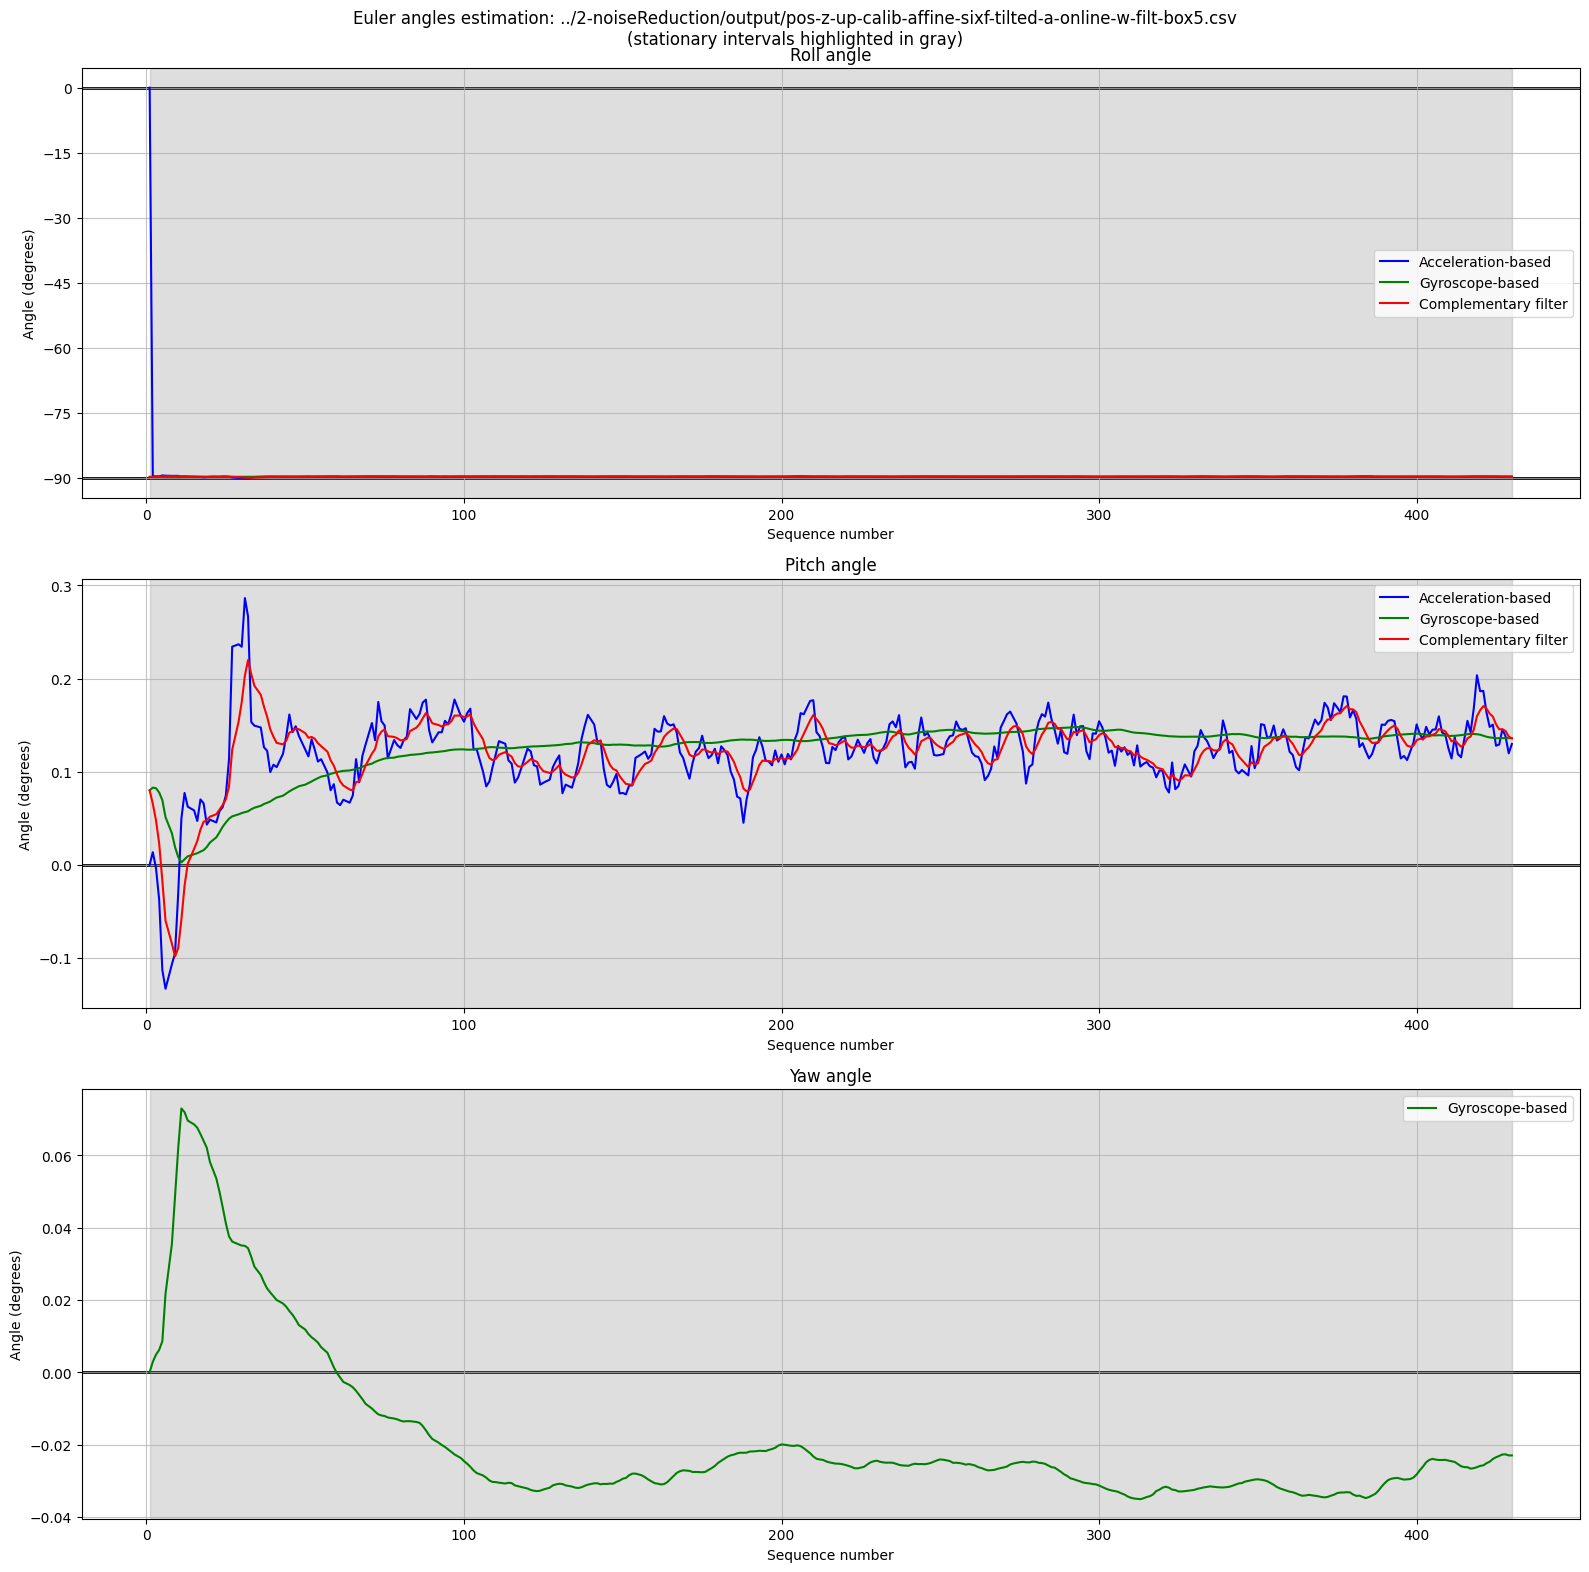

In [72]:
gyroAngles = gyroOnlyOrientationDirectIntegration(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="simple",
    accelBranch="main",
)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

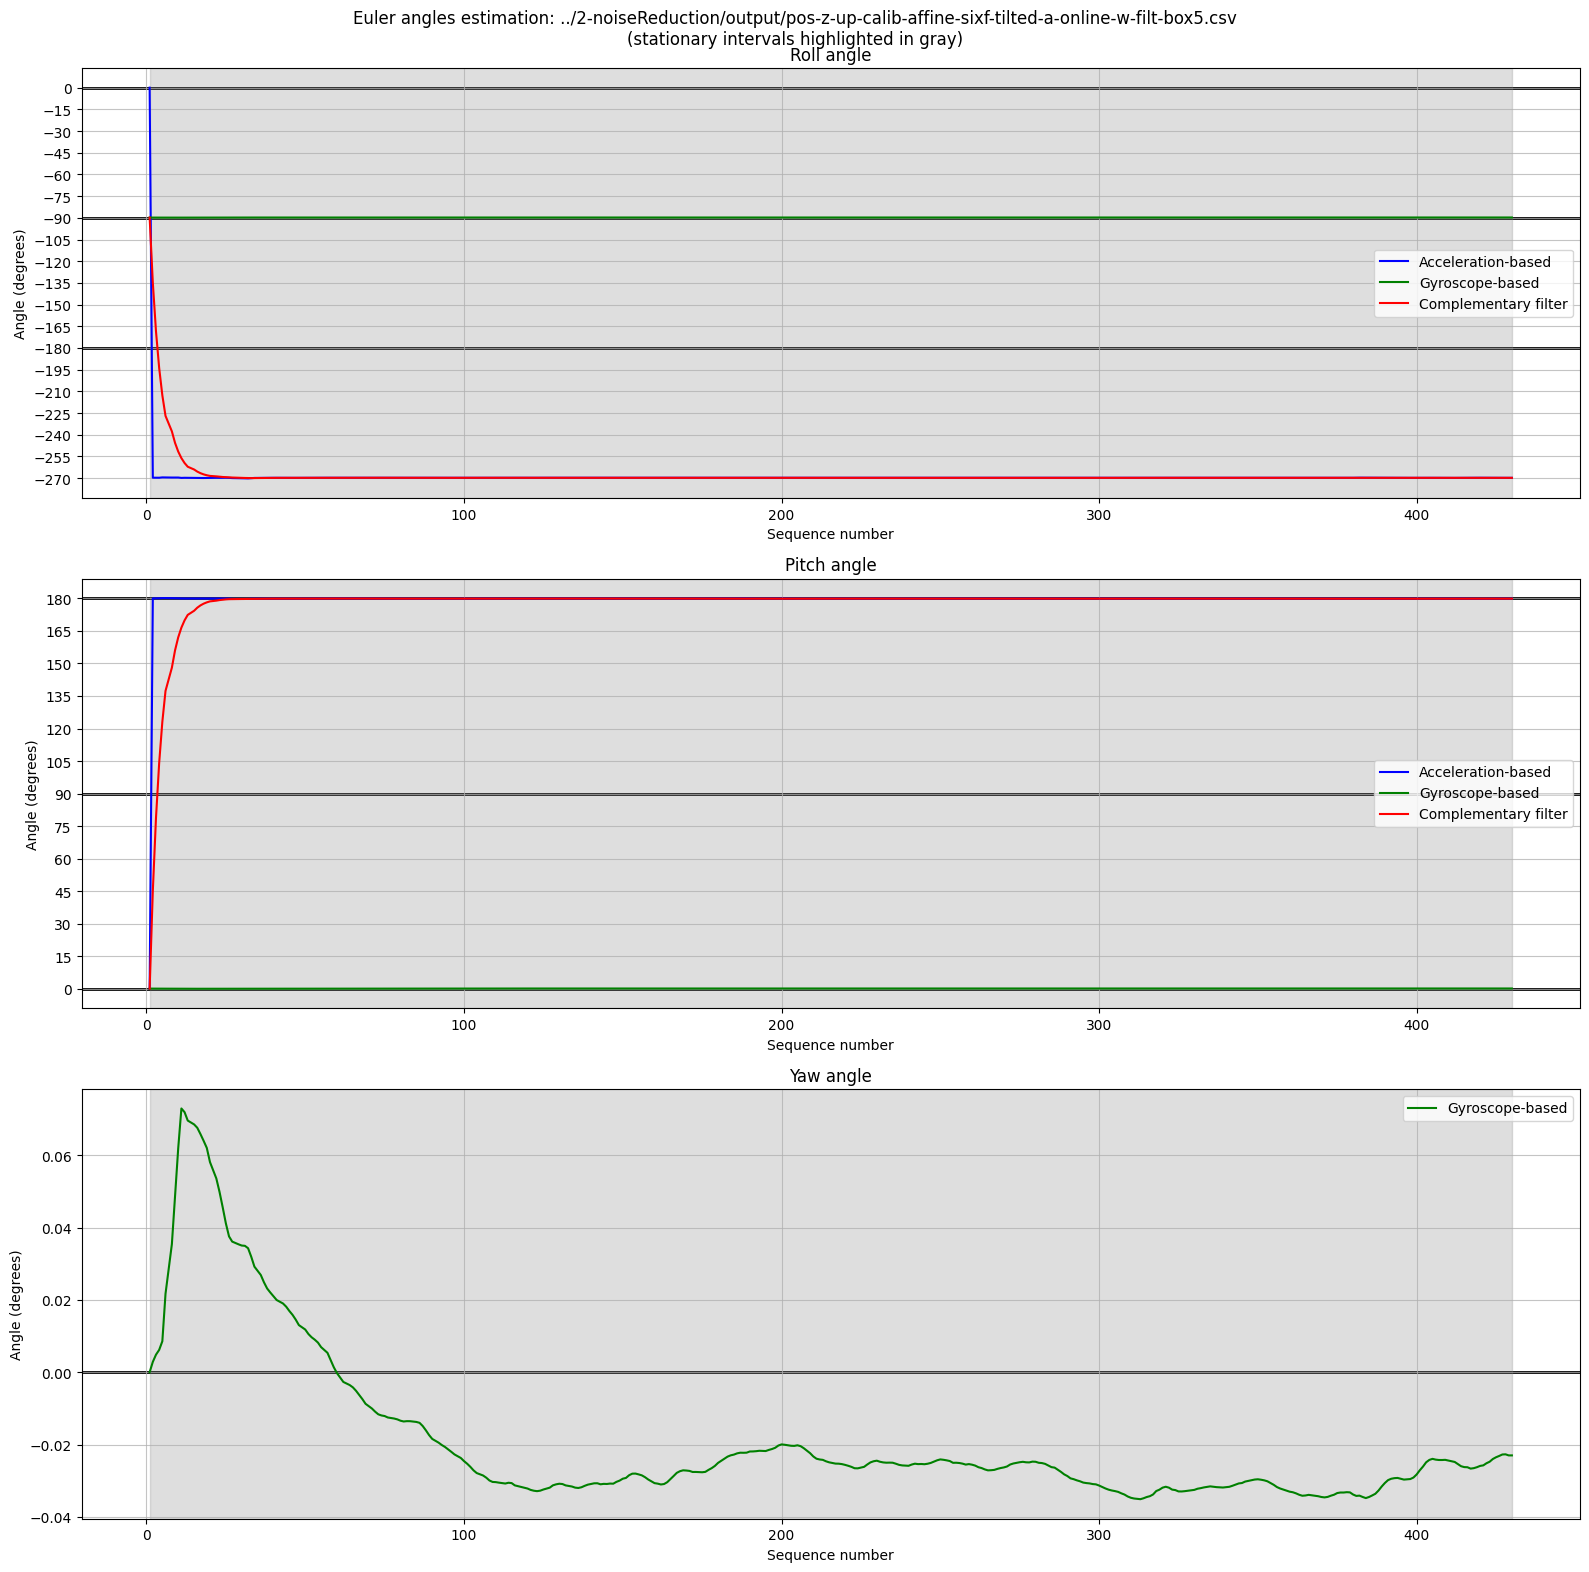

In [73]:
gyroAngles = gyroOnlyOrientationDirectIntegration(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="simple",
    accelBranch="alt",
)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

### Corrected formula

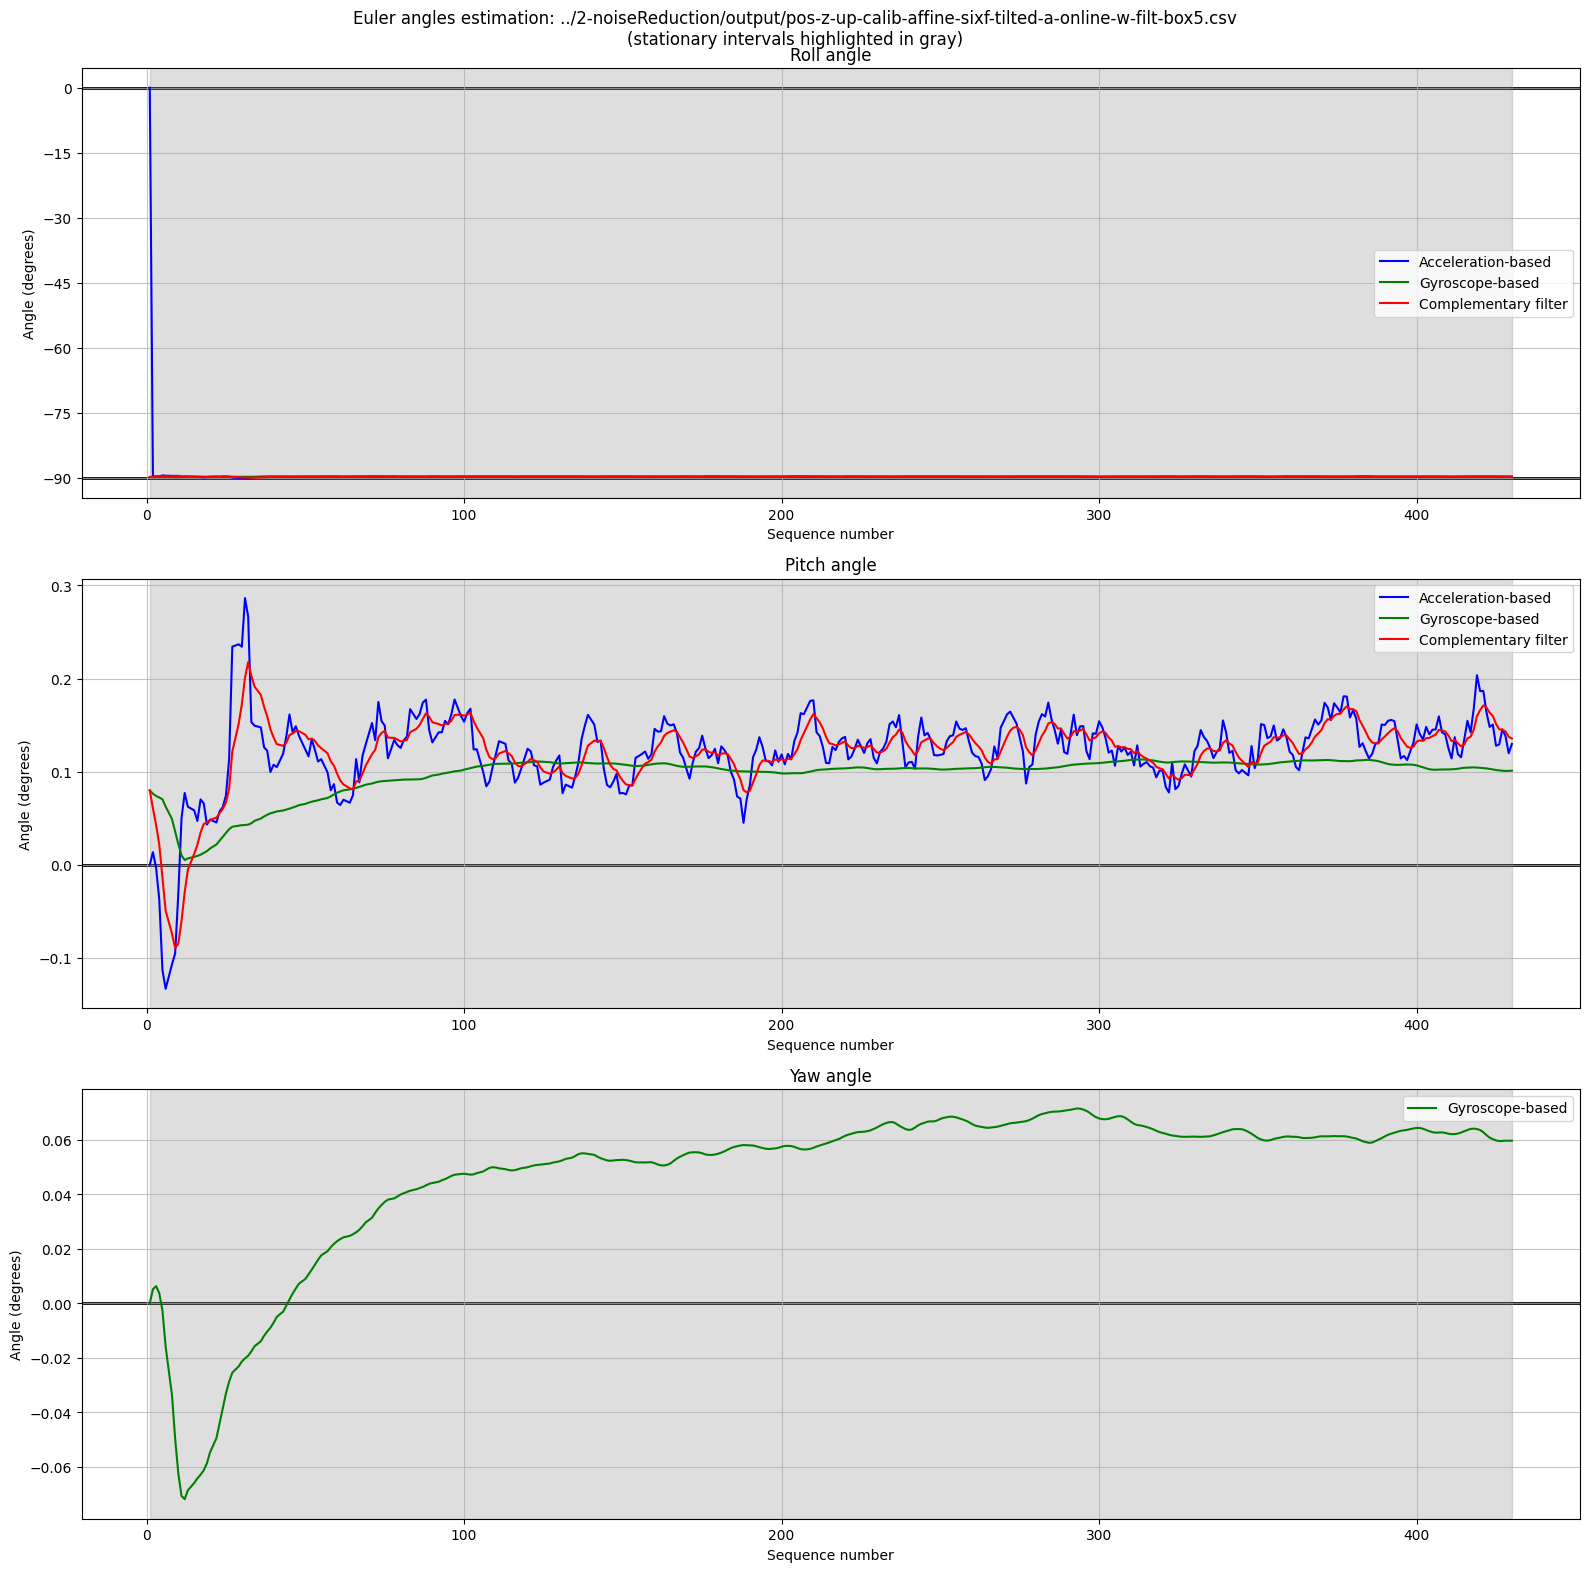

In [74]:
gyroAngles = gyroOnlyOrientationNonLinearTransform(a, w, dt)
accelAngles, complementaryAngles = complementaryFilterOrientation(
    seq,
    a,
    w,
    dt,
    stationaryChecker,
    alphaStationary,
    alphaMoving,
    gyroMethod="non-linear",
)
plotEulerAngles(
    seq, gyroAngles, accelAngles, complementaryAngles, stationaryIntervals, capturePath
)

# Conclusion

After analyzing real exercises data against video recordings and getting a feeling of angles with a protractor, the complementary filter seems to work decently for the motions of this application. However, there are some limitations:

* Some angles are inherently problematic, namely $\pm 90^\circ$ and $\pm 180^\circ$.

* The workarounds discussed earlier (protection of atan2 against noise, motion detection, angle decision, two alphas) are not perfect and add some complexity and computation time, which goes against the goal of simplicity that was intended with this filter. 

* Chatting with AI, I discovered that integrating gyroscope data directly is only an approximation: true euler angles supposedly can be computed with:

$$
\dot{\phi} = p + q\sin\phi\tan\theta + r\cos\phi\tan\theta \\
\dot{\theta} = q\cos\phi - r\sin\phi \\
\dot{\psi} = q\frac{\sin\phi}{\cos\theta} + r\frac{\cos\phi}{\cos\theta}
$$

In other words, a non-linear transformation has to be applied to the gyroscope data before integration, which is not implemented in this filter. Notice that errors stay bounded for relatively small angles (especially not close to Euler singularities) and moderate dynamics and also thanks to the acceleration contribution to estimation. The original application of the complementary filter was for 1D or 2D tilt estimation, not full-blown 3D orientation estimation.

A future iteration should consider a more advanced sensor fusion algorithm and another representation of orientation.